In [1]:
pip install tensorflow==2.12 pillow


  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ---------------------------------------- 0

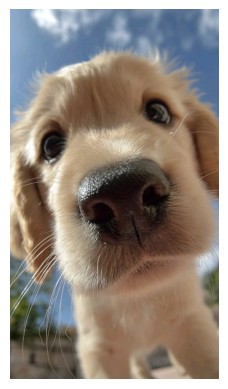

1/1 [==============================] - 0s 296ms/step
Класс: 1 dogs

Уверенность: 1.0


In [12]:
from tensorflow.keras.models import load_model
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import numpy as np

# загрузка модели
model = load_model("keras_model.h5", compile=False)

# классы
class_names = open("labels.txt", "r").readlines()

# массив
data = np.ndarray(shape=(1, 224, 224, 3), dtype=np.float32)

# загрузка изображения
image = Image.open(r"H:\animal\images.cv_4zntidyn4w94o8tql8c9g5\data\test\animal dog\211174978496540.jpg").convert("RGB")

# показать изображение
plt.imshow(image)
plt.axis('off')
plt.show()

# изменение размера
size = (224, 224)
image = ImageOps.fit(image, size, Image.Resampling.LANCZOS)

# преобразование
image_array = np.asarray(image)

# нормализация
normalized_image_array = (image_array.astype(np.float32) / 127.5) - 1

# загрузка в массив
data[0] = normalized_image_array

# предсказание
prediction = model.predict(data)

index = np.argmax(prediction)
class_name = class_names[index]
confidence_score = prediction[0][index]

print("Класс:", class_name)
print("Уверенность:", confidence_score)